---
title: "Scatter Plots"
subtitle: "DS 2023 | Communicating with Data"
---

:::{image}https://ontoligentdesign.com/ds2023/images/scatter-plot.png
:width: 500px
:align: left
:::

## Overview

A scatter plot uses **dots** to represent the values of **two numeric variables** on a cartesian plane.

The domains of two variables from a data frame are mapped onto the x and y axes to generate a $2D$ space.

Within this space, each dot on the plot represents an **observation**, i.e. a row of data. 

Conversely, each row in the source data frame is a **coordinate**.

## Use Cases

Scatter plots can be used to identify **relationships**, **trends**, **patterns**, **clusters**, and **outliers** among the data points.

A common use case is to  plot an **independent** variable (e.g. time) on the x-axis and a **dependent** variable on the y-axis.

In this case and other, scatter plots allow you to visually assess how strongly two variables are **correlated**.

Frequenty, scatter plots feature **regression lines**.

:::{note}
Typically, scatter plots are **cropped**: The x and y axes are not zero based but are instead clipped to contain only the points in the data set. This is because the purpose of the plot is to show **relationship**, not magnitude. 
:::

## Createing a scatter plot from scratch

Let's generate some random numeric data.

We use NumPy's random number generator that samples from the normal distribution to create a data frame with $1000$ observations of $2$ features.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.DataFrame({
    'f1': np.random.randn(1000),
    'f2': np.random.randn(1000)
})
df.head()

,f1,f2
0,0.014711,-0.399631
1,0.109826,-0.399905
2,0.392914,1.495582
3,-0.606651,-1.104250
4,-1.891150,1.641964


To understand the logic of a scatter plot, consider how we'd create one by hand.

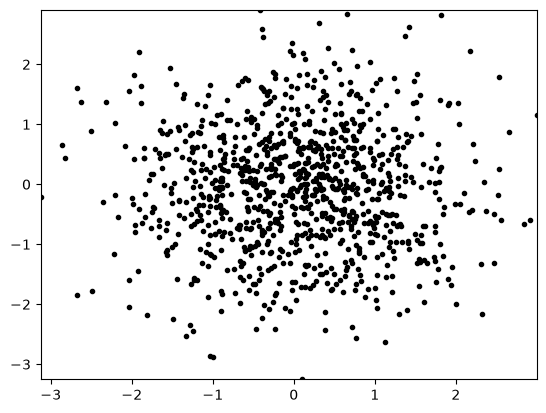

In [89]:
fig, ax = plt.subplots()

# Scale the axes
ax.set_xlim(left=df.f1.min(), right=df.f1.max())
ax.set_ylim(bottom=df.f2.min(), top=df.f2.max())

# Plot each point
for idx, row in df.iterrows():
    plt.plot(row.f1, row.f2, '.', c='black')

Pandas' `.plot.scatter()` method does this for us.

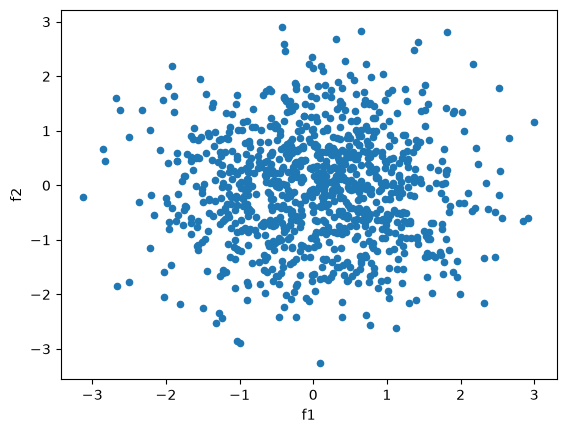

In [48]:
df.plot.scatter(x='f1', y='f2')
plt.show()

Because both features are drawn from the normal distribution, they should exhibit no correlation. 

Indeed, the result is a random blob of points that cluster around $0$, the mean.

## A better example

Let's look at a better example, one involve real data.

We import the Penguins data set from Seaborn.

In [37]:
penguins = sns.load_dataset('penguins').dropna()
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Here is a scatter plot of two features.

Note that the plot effectively zooms in one the data by cropping the axes.

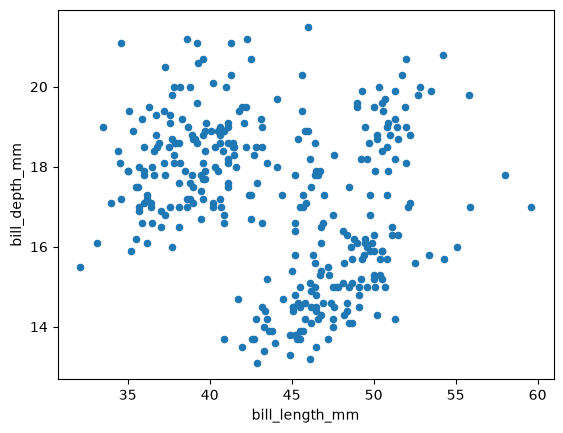

In [38]:
penguins.plot.scatter(x='bill_length_mm', y='bill_depth_mm')
plt.show()

If the axes are not cropped, you get something like this:

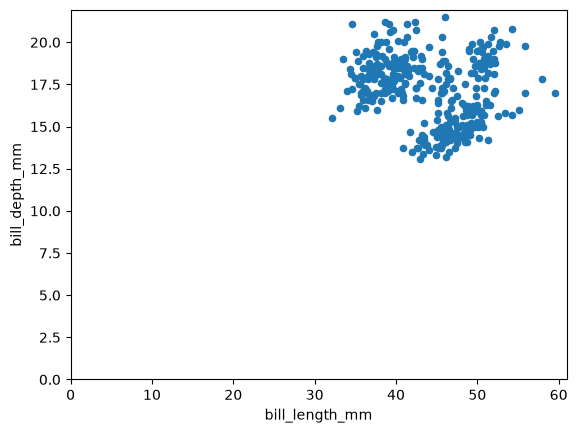

In [47]:
penguins.plot.scatter(x='bill_length_mm', y='bill_depth_mm', xlim=(0, None), ylim=(0, None))
plt.show()

## Showing a third feature with color

If you want to map the distribution of `species` onto the figure, you can associate color with the feature.

:::{note} 
The ability to pass a feature name to `c` is only available in Pandas 3.
:::

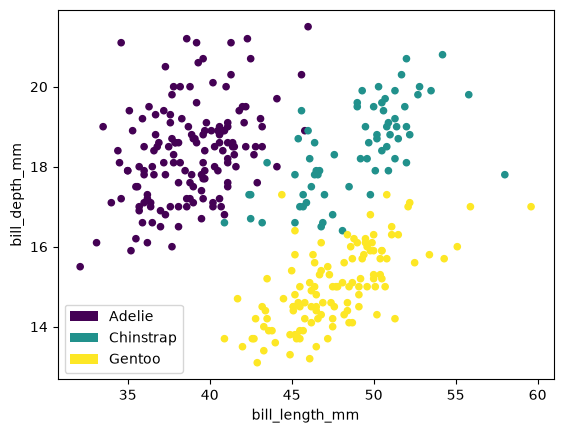

In [50]:
penguins.plot.scatter(x='bill_length_mm', y='bill_depth_mm', c='species')
plt.show()

The result shows that the observations **cluster** in the space created by the features.

This indicates that the features may be predictive of species.

:::{caution}
If you pass to `c` a feature of the type `category` &mdash; which seems like a reasonable thing to do &mdash; the result will be different from what you see below. The legend will change to a segmented color bar on the right. Additionally, it may be necessary to set the `cmap` parameter, since one of the colors Pandas chooses in this context is white, which makes the points invisible.
:::

## Showing a third feature with size

We might also choose to change the size of each data point in proportion to a numeric features.

Here we invent a feature `size_factor` to display for demonstration purposes.

We chould have just used `body_mass_g`, but this results in very large circles.

In [22]:
penguins['size_factor'] = (penguins.body_mass_g - penguins.body_mass_g.min())/10

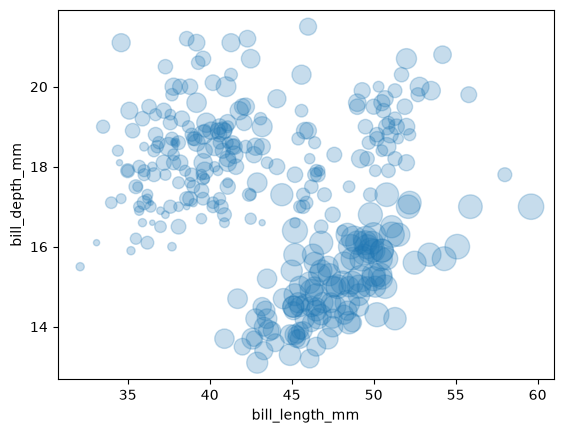

In [23]:
penguins.plot.scatter(
    x='bill_length_mm', 
    y='bill_depth_mm', 
    s='size_factor', 
    alpha=.25)
plt.show()

## Showing features with color and size

It's actually pretty easy to show four features.

Here we use both color and size as **channels** on which to map a categorical and numeric feature respectively.

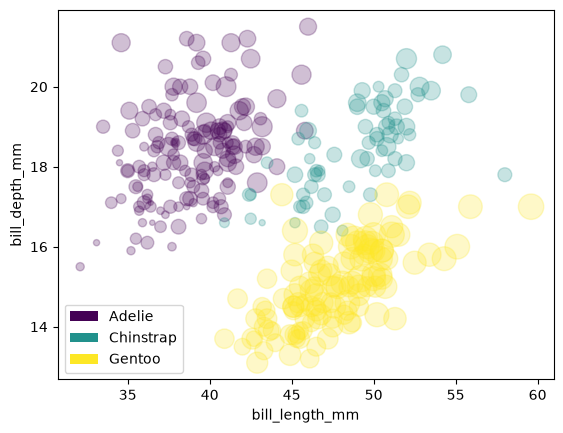

In [9]:
penguins.plot.scatter(
    x='bill_length_mm', 
    y='bill_depth_mm', 
    c='species',
    s='size_factor', 
    alpha=.25)
plt.show()

## Scatter matrices (lattices)

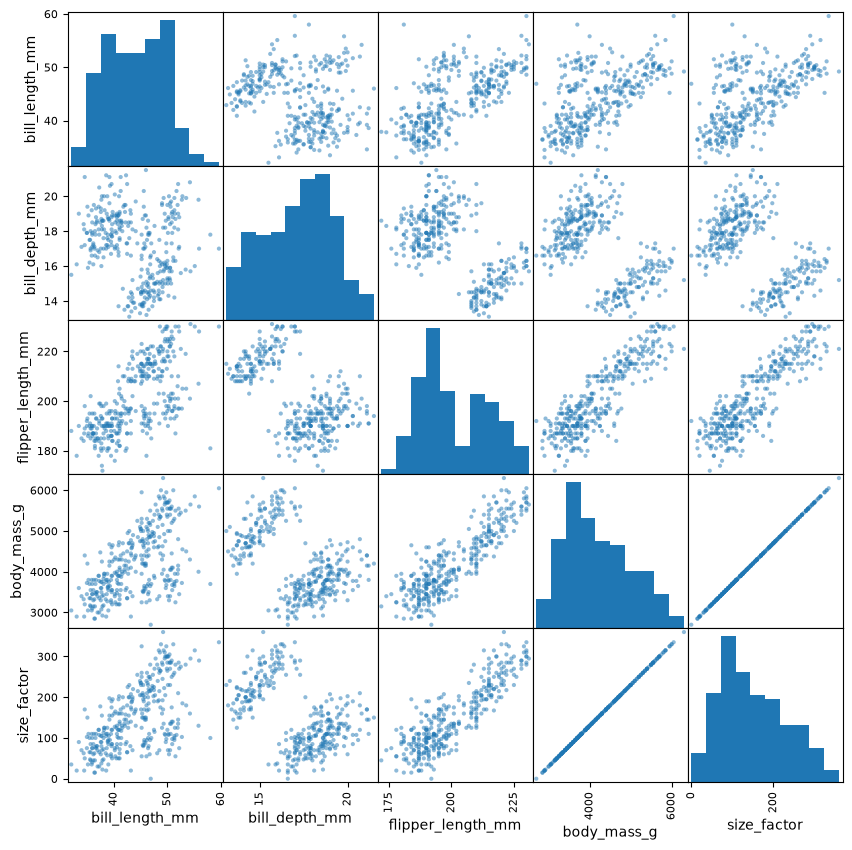

In [10]:
pd.plotting.scatter_matrix(penguins, figsize=(10,10))
plt.show()

## Another example: Regression

In [11]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [12]:
tips['tip_pct'] = tips.total_bill / tips.tip
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,16.821782
1,10.34,1.66,Male,No,Sun,Dinner,3,6.228916
2,21.01,3.50,Male,No,Sun,Dinner,3,6.002857
3,23.68,3.31,Male,No,Sun,Dinner,2,7.154079
4,24.59,3.61,Female,No,Sun,Dinner,4,6.811634


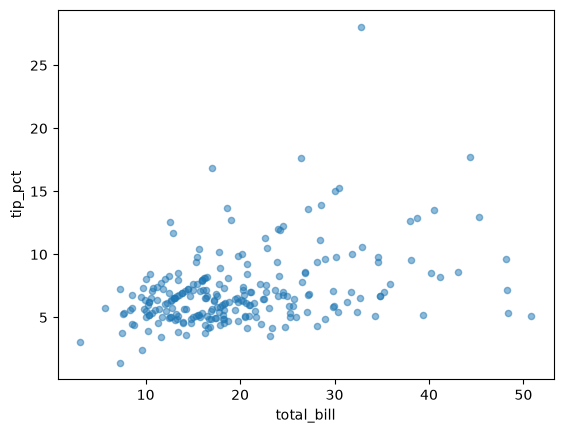

In [13]:
tips.plot.scatter(x='total_bill', y='tip_pct', style='.', alpha=.5)
plt.show()

In [14]:
m, b = np.polyfit(tips.total_bill, tips.tip, 1)
tips['total_bill_y'] = tips.total_bill * m + b
print('Expected tip = ', round(m,2))

Expected tip =  0.11


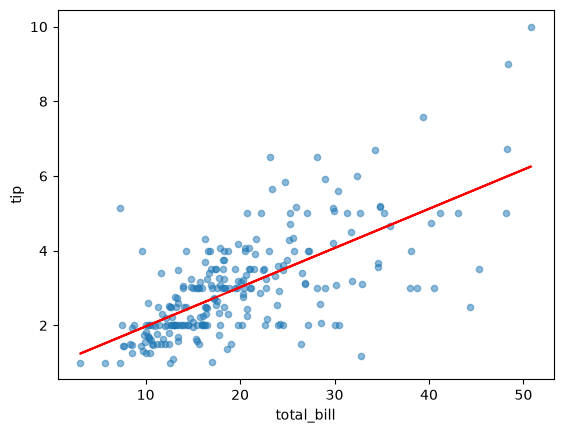

In [15]:
ax = tips.plot.scatter(x='total_bill', y='tip', alpha=0.5)
tips.plot.line(x='total_bill', y='total_bill_y', ax=ax, c='red', legend=False)
plt.show()

In [16]:
float(tips.tip_pct.mean().round(2))

7.05

## Anscombe's Quartet

All four of these data sets have the same summary statistics.

In [17]:
anscombe = sns.load_dataset('anscombe')

In [18]:
def compute_regression(x, y):
    m, b = np.polyfit(x, y, 1)
    return x * m + b

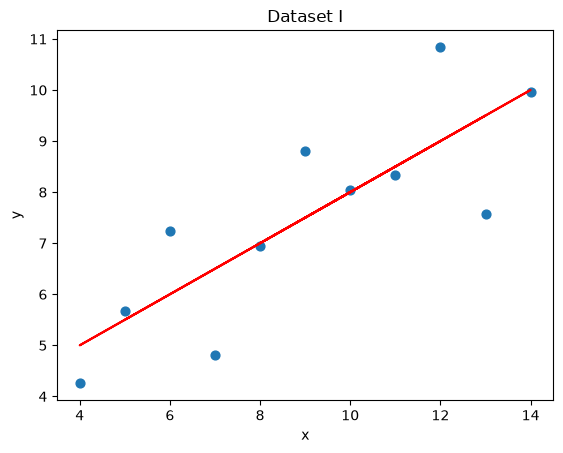

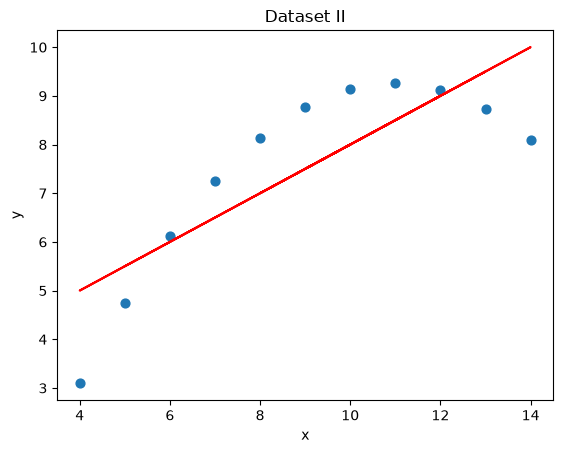

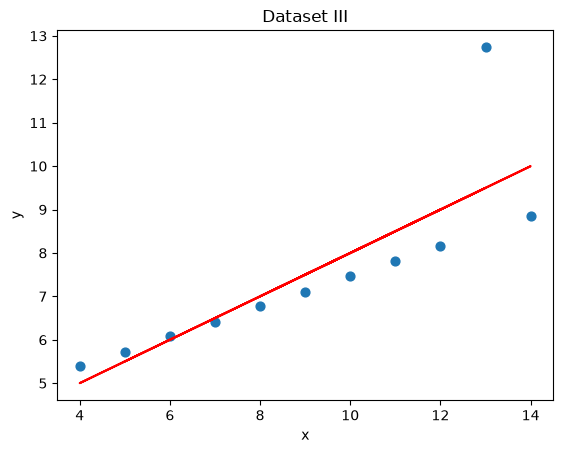

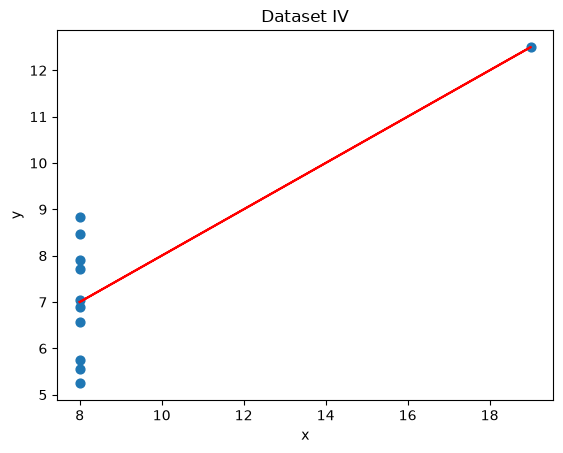

In [19]:
for ds_name, ds in anscombe.groupby('dataset'):
    ax = ds.plot.scatter(x='x', y='y', title=f"Dataset {ds_name}", s=40)
    ds['y_hat'] = compute_regression(ds.x, ds.y)
    ds.plot.line(x='x', y='y_hat', ax=ax, color='red', legend=False)
    plt.show()

## Review

- Compares numeric features
- Correlation
- Clustering